In [3]:
import numpy
from torchvision.datasets import ImageFolder
import re
from PIL import Image
import pandas as pd

First we need to preprocess our data. Images are saved using RGB. We need to convert entire color space into n classes. We will use K-Means clustering algorithm for that.

In [5]:
data = ImageFolder("data/train")
print((data[0][0]))

<PIL.Image.Image image mode=RGB size=320x213 at 0x1173CCD70>


In [6]:
print(data.imgs[0])
print(((data.imgs[0][0]).split("/")[-1]).split(".")[0])

('data/train/all/10043234166_e6dd915111_n.jpg', 0)
10043234166_e6dd915111_n


In [7]:
def img_resize_and_save(image,dir_path,filename):
    resized_img = image.resize((300,200))
    resized_img.save(dir_path + filename+".jpg")

In [8]:
img_resize_and_save(data[0][0],'',((data.imgs[0][0]).split("/")[-1]).split(".")[0])

In [10]:
i = 0
while i < len(data):
    img_resize_and_save(data[i][0],'dataset/resized_color/',((data.imgs[i][0]).split("/")[-1]).split(".")[0])
    i+=1


Now we have a dataset of 300x200 pixels. The next step is to transform them to X -> Y.
For this purpose we will transform those images to grayscale (X) and matrixes of color cluster indexes (Y). In order to achieve that we have to run KMeans algorithm on CIE LAB version of those images (only a and b)

In [38]:
import os
from os import listdir
from PIL import Image, ImageOps

# get the path/directory
folder_dir = "dataset/resized_color"
imagesTable = []
for images in os.listdir(folder_dir):
    # check if the image ends with png
    if (images.endswith(".jpg")):
        with Image.open("dataset/resized_color/" + images) as im:
            im1 = ImageOps.grayscale(im)
            im1.save("dataset/grayscale/" + images)




In [11]:
import numpy as np
from skimage import io, color

rgb_img = io.imread("test.jpg")
print(type(rgb_img))
print(rgb_img[0][0])

rgb_norm = rgb_img / 255.0

print(rgb_norm[0][0])

cie_lab_img = color.rgb2lab(rgb_norm)
print(type(cie_lab_img))


<class 'numpy.ndarray'>
[6 7 2]
[0.02352941 0.02745098 0.00784314]
<class 'numpy.ndarray'>


In [29]:
# test działania konwersji z rgb do cie lab i na odwrót

from skimage import img_as_ubyte
goback = color.lab2rgb(cie_lab_img)
print(goback[0][0])
goback = img_as_ubyte(goback)
print(goback[0][0])
print(io.imsave("t.jpg",goback))

[0.02352941 0.02745098 0.00784314]
[6 7 2]
None


In [39]:
# get the path/directory
import numpy as np
folder_dir = "dataset/resized_color"
for images in os.listdir(folder_dir):
    # check if the image ends with png
    if (images.endswith(".jpg")):
            im_rgb = io.imread("dataset/resized_color/" + images)
            im_cie_lab = color.rgb2lab(rgb_norm)
            np.save("dataset/cie_lab/" + images.split('.')[0] + ".npy",im_cie_lab)

In [45]:
import seaborn as sns
import random

In [55]:
dir_path = "dataset/cie_lab"
images = os.listdir("dataset/cie_lab")
images_to_kmeans = random.choices(images,k=100)
pixels = []
for image_name in images_to_kmeans:
    if image_name.endswith(".npy"):
        image_lab = np.load(dir_path + '/' + image_name)
        ab = image_lab[:, :, 1:3]
        ab = ab.reshape(-1,2)
        pixels.append(ab)
pixels = np.concatenate(pixels,axis=0)
print(pixels.shape)


(6000000, 2)


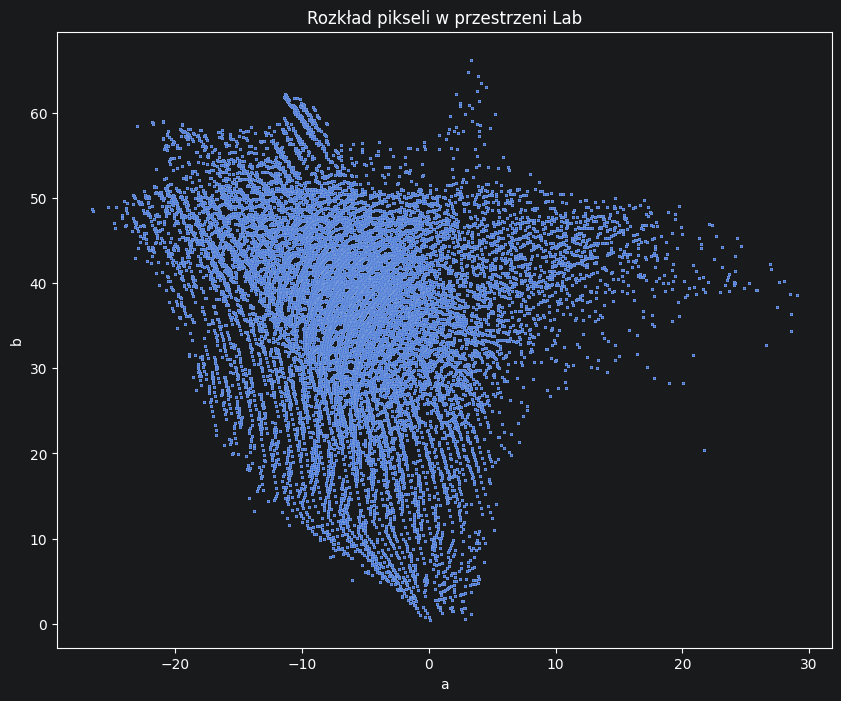

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# pixels shape = (N, 2)

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=pixels[:, 0],
    y=pixels[:, 1],
    s=4,
    alpha=0.15,
)

plt.xlabel("a")
plt.ylabel("b")
plt.title("Rozkład pikseli w przestrzeni Lab")
plt.show()

In [73]:
from sklearn.cluster import MiniBatchKMeans
import numpy as np
import joblib

K = 64

kmeans = MiniBatchKMeans(
    n_clusters=K,
    batch_size=10000,
    random_state=42,
    verbose=1
)

kmeans.fit(pixels)

np.save("centroids.npy", kmeans.cluster_centers_)
joblib.dump(kmeans, "kmeans.pkl")

print("Gotowe")

Init 1/1 with method k-means++
Inertia for init 1/1: 88039.89008493954
Minibatch step 1/60000: mean batch inertia: 2.9820034526965666
Minibatch step 2/60000: mean batch inertia: 2.678199240267274, ewa inertia: 2.678199240267274
Minibatch step 3/60000: mean batch inertia: 2.5476278730588042, ewa inertia: 2.6777640024491185
Minibatch step 4/60000: mean batch inertia: 2.5839035684914435, ewa inertia: 2.677451134388071
Minibatch step 5/60000: mean batch inertia: 2.5821640965475474, ewa inertia: 2.6771335109815397
Minibatch step 6/60000: mean batch inertia: 2.5026314192003833, ewa inertia: 2.6765518374392148
Minibatch step 7/60000: mean batch inertia: 2.5364836678778984, ewa inertia: 2.6760849436184926
Minibatch step 8/60000: mean batch inertia: 2.639739708641782, ewa inertia: 2.6759637928554287
Minibatch step 9/60000: mean batch inertia: 2.4719861018232985, ewa inertia: 2.675283867331976
Minibatch step 10/60000: mean batch inertia: 2.5208328427451643, ewa inertia: 2.674769030669159
Minibat

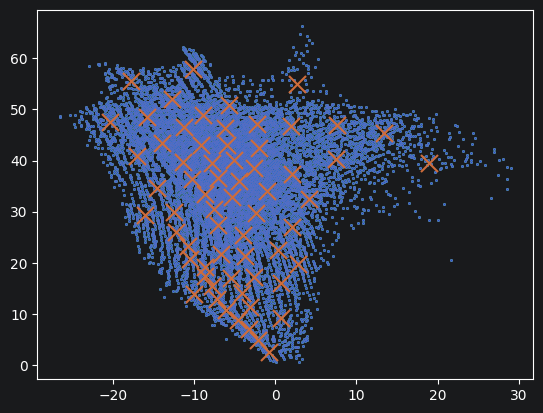

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x=pixels[:, 0],
    y=pixels[:, 1],
    s=3,
    alpha=0.05
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=150,
    marker='x'
)

plt.show()

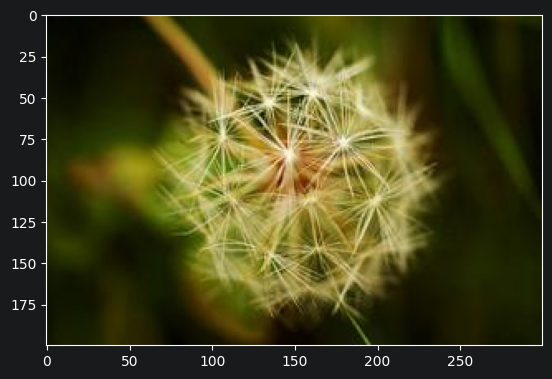

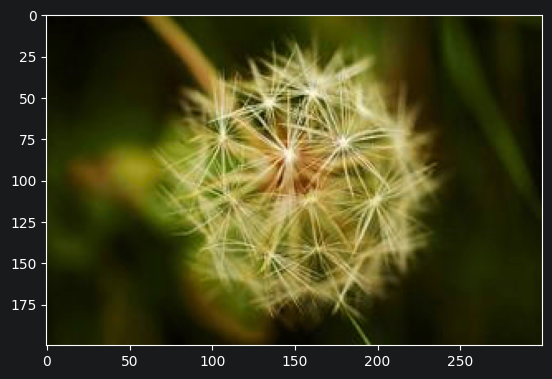

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import lab2rgb
lab = np.load("testlab.npy")
rgb = lab2rgb(lab)
plt.imshow(rgb)
plt.show()
ab = lab[:, :, 1:3]
shape = ab.shape[:2]

labels = kmeans.predict(ab.reshape(-1, 2))

reconstructed_ab = kmeans.cluster_centers_[labels]
reconstructed_ab = reconstructed_ab.reshape(shape[0], shape[1], 2)

new_lab = lab.copy()
new_lab[:, :, 1:3] = reconstructed_ab


rgb = lab2rgb(new_lab)

plt.imshow(rgb)
plt.show()